In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import seaborn as sns

# For venn diagram
from matplotlib_venn import venn3, venn2
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based


plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6

In [2]:
colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


cat_colors_map = dict(zip(unique_categories, colors_list))                  
cat_labels_map = dict(zip(unique_categories, unique_categories))


filtering_set = ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']
filtering_set_labels = ['CR nuclei', 'SADE nuclei', 'TSSe nuclei']
filtering_set_label_map = dict(zip(filtering_set, filtering_set_labels))

jitter_width = 0.25
position_offset = [0] + [-jitter_width] * 3 + [jitter_width] * 3  # Adjust offsets for each category
cat_position_map = dict(zip(unique_categories, position_offset))

In [3]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 2 + [jitter_width] * 2  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))


SADEvsCR_filteringset = [ 'atac_pass_CR', 'atac_pass_entropy',]

In [4]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1, norm=None):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    try:
        ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors, norm=norm) # s controls point size
    except Exception:
        ax.scatter(x_jittered, data_group, c=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, norm=norm) # fallback without edgecolors for older matplotlib versions

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [5]:
entropy_dir ='/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/'

entropy_all_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
print(entropy_df.shape) 
entropy_df.head(2)

(33287, 8)


,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


In [6]:
# Load union set cells 
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


In [7]:
col_list = [ '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac']
for col in col_list:
    entropy_df[col] = entropy_df['atac_bc'].map(union_cell_info[col]).fillna('none')
#entropy_df.head(2)

In [8]:
# Load fragments file
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_barcodes'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])



frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_raw_peaks.index.name ='atac_barcodes'
frag_in_raw_peaks.columns = ['chrom', 'start', 'end', 'support']


entropy_df['total_fragments'] = entropy_df.index.map(frag.groupby('atac_barcodes').size())
entropy_df['Nfrag_in_rawpeaks'] = entropy_df.index.map(frag_in_raw_peaks.groupby('atac_barcodes').size()).fillna(0).astype(int)
entropy_df['frip_rawpeaks'] = entropy_df['Nfrag_in_rawpeaks'] / entropy_df['total_fragments']


rawpeaks_subdir = os.path.join(Union_cell_subdir, 'Rawpeaks')
frag_in_rawpeaks_file = os.path.join(rawpeaks_subdir, 'frag_overlap', 'frag_in_peaks.tsv')

col_names = ['chrom', 'start', 'end', 'atac_barcode', 'support']
frag_in_rawpeaks_df = pd.read_csv(frag_in_rawpeaks_file, sep='\t', names=col_names)
frag_in_rawpeaks_df['atac_bc'] = frag_in_rawpeaks_df['atac_barcode'].str.split('-').str[0]
print(frag_in_rawpeaks_df.head(2))


Nfrag_in_rawpeaks_per_bc = frag_in_rawpeaks_df.groupby('atac_bc').size()
union_cell_info['Nfrag_in_rawpeaks'] = union_cell_info.index.map(Nfrag_in_rawpeaks_per_bc).fillna(0).astype(int)
union_cell_info['frip_rawpeaks'] = union_cell_info['Nfrag_in_rawpeaks'] / union_cell_info['total_fragments']

  chrom   start     end        atac_barcode  support           atac_bc
0  chr1  816905  817256  TGCGGAATCTAACTAC-1        1  TGCGGAATCTAACTAC
1  chr1  816915  817244  GTTTGTGTCGCTAGCT-1        1  GTTTGTGTCGCTAGCT


In [9]:
entropy_df['log_entropy'] = np.log2(entropy_df['Entropy'])
entropy_df['log_total_fragments'] = np.log1p(entropy_df['total_fragments'])

union_cell_info['log_entropy'] = np.log2(union_cell_info['Entropy'])
union_cell_info['log_total_fragments'] = np.log1p(union_cell_info['total_fragments'])

In [10]:
# Those in the union set but in neither of CR or SADE are uniquely identified by TSS enrichment
union_cell_info['_2set_identified_by_atac_SC_mod'] = union_cell_info['_2set_identified_by_atac_SC'].replace('none', 'tss_only')

# Print read depth stats

In [11]:
for set_name in ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']:
    print(f"Statistics for {set_name}:")
    print(union_cell_info.loc[union_cell_info[set_name] == True, 'total_fragments'].describe())
    print('----------')

Statistics for atac_pass_CR:
count    1.959000e+03
mean     2.209744e+04
std      1.235443e+05
min      3.820000e+02
25%      3.968000e+03
50%      8.086000e+03
75%      1.368200e+04
max      2.214078e+06
Name: total_fragments, dtype: float64
----------
Statistics for atac_pass_entropy:
count      2101.000000
mean      10207.656354
std       20353.415891
min         262.000000
25%        3213.000000
50%        7159.000000
75%       12718.000000
max      398925.000000
Name: total_fragments, dtype: float64
----------
Statistics for atac_pass_archr_TSS:
count     2132.000000
mean      8839.997186
std       8096.578374
min       1000.000000
25%       2879.250000
50%       6857.000000
75%      12464.250000
max      93677.000000
Name: total_fragments, dtype: float64
----------


# Venn comparison

In [12]:
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,total_fragments,Nfrag_in_rawpeaks,frip_rawpeaks,log_entropy,log_total_fragments
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA,none,none,none,537,0,0.000000,-7.591694,6.287859
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT,both,both,common,4841,2740,0.565999,-2.294087,8.485083


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


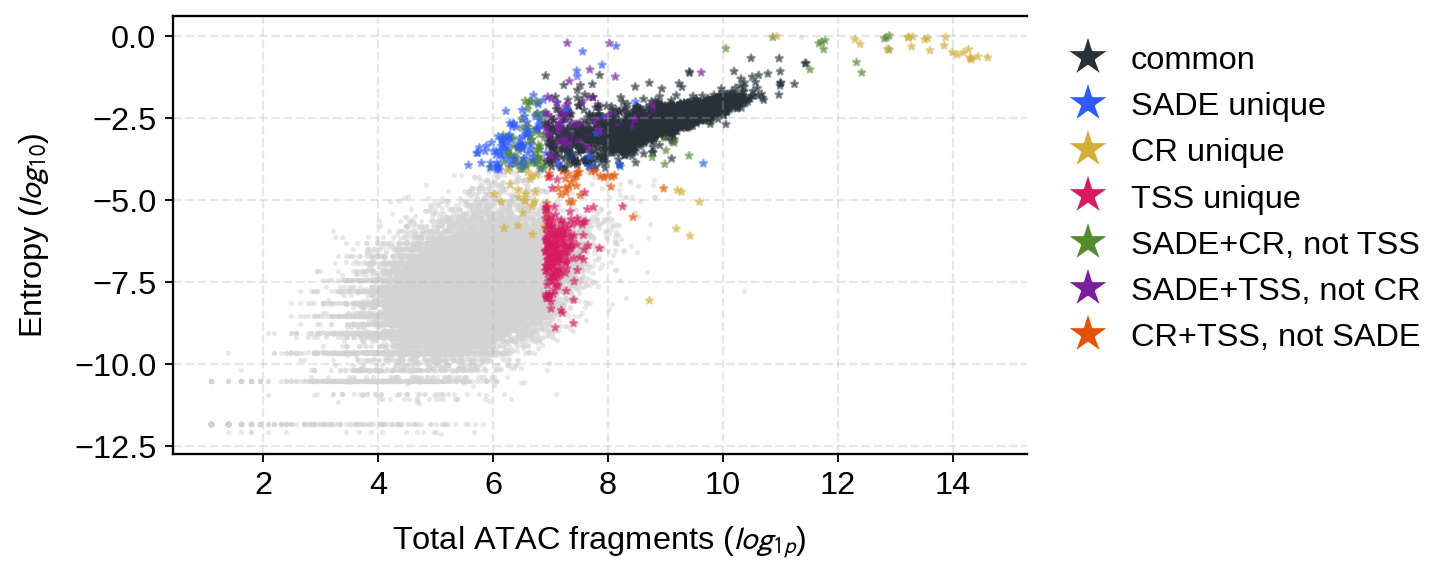

In [13]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

# droplets not in any of the 3 sets are colored in light gray
not_in_any_set = ~entropy_df['atac_bc'].isin(union_cell_info.index)
ax.scatter( entropy_df.loc[not_in_any_set, 'log_total_fragments'], 
            entropy_df.loc[not_in_any_set, 'log_entropy'], 
            c='lightgray',
            marker='o', 
            s=5,
            alpha=0.5,
            lw=0,)
# Now the droplets in the union set are colored by their category 
ax.scatter( union_cell_info['log_total_fragments'], union_cell_info['log_entropy'],  c= union_cell_info['_3set_identified_by_atac'].map(cat_colors_map), 
            alpha=0.5, 
            s=10,          
            lw=1,      
            marker='*',   
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log_{1p}$)', labelpad=10)
ax.set_ylabel('Entropy ($log_{10}$)', labelpad=10)


handles = [Line2D([0], [0], marker='*', color='w', markerfacecolor=v, label=k, markersize=20) for k, v in cat_colors_map.items()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.3)



_3set_identified_by_atac
CR unique           12
TSS unique           9
CR+TSS, not SADE     1
Name: count, dtype: int64
                          count      mean       std       min       25%  \
_3set_identified_by_atac                                                  
CR unique                  12.0  0.677933  0.077673  0.548387  0.626765   
CR+TSS, not SADE            1.0  0.573248       NaN  0.573248  0.573248   
TSS unique                  9.0  0.050321  0.013691  0.034466  0.040636   

                               50%       75%       max  
_3set_identified_by_atac                                
CR unique                 0.673707  0.746291  0.773913  
CR+TSS, not SADE          0.573248  0.573248  0.573248  
TSS unique                0.043478  0.066524  0.070270  


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


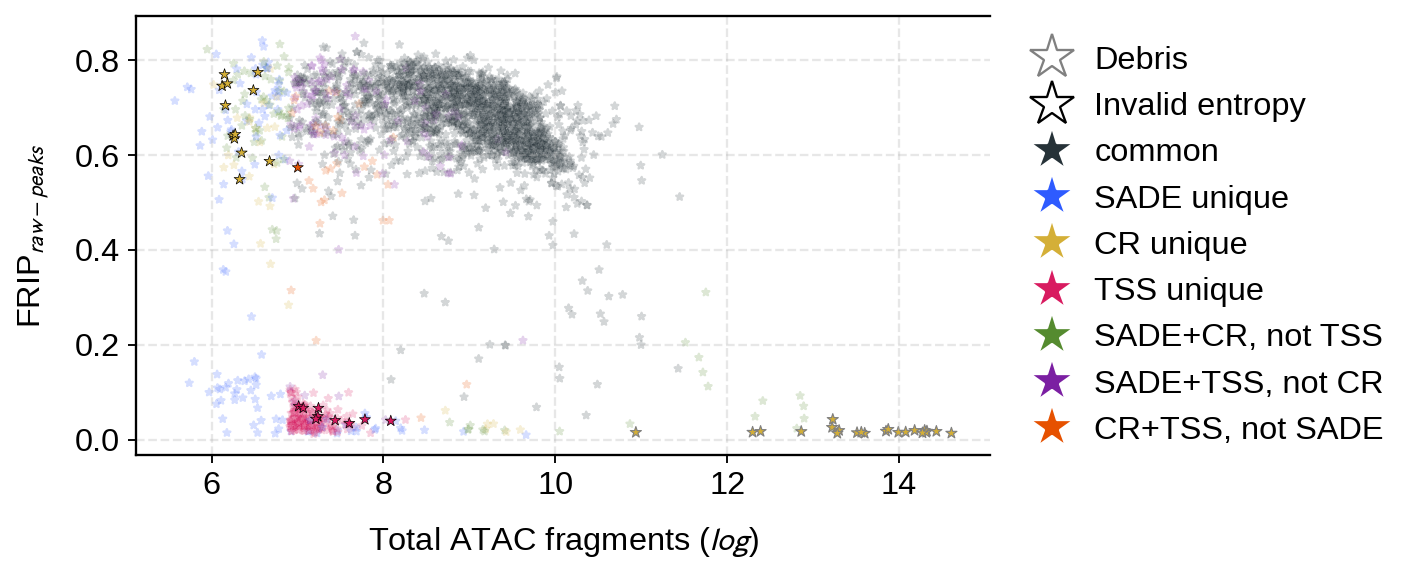

In [14]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

dna_debris_index = union_cell_info['DNA_debris'] == 'YES'
invalid_entropy_index = union_cell_info['Entropy'].isna()

# Only the droplets in the union set are colored by their category 
## For non-DNA-debris droplets, color by their category
ax.scatter( union_cell_info.loc[(~dna_debris_index) & (~invalid_entropy_index), 'log_total_fragments'], union_cell_info.loc[(~dna_debris_index) & (~invalid_entropy_index), 'frip_rawpeaks'],  edgecolors= union_cell_info.loc[(~dna_debris_index) & (~invalid_entropy_index), '_3set_identified_by_atac'].map(cat_colors_map), 
            c='white', alpha=0.2, 
            s=10,          
            lw=1,      
            marker='*', 
              
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For DNA-debris droplets, edgecolor in black 
ax.scatter( union_cell_info.loc[dna_debris_index, 'log_total_fragments'], union_cell_info.loc[dna_debris_index, 'frip_rawpeaks'],  c= union_cell_info.loc[dna_debris_index, '_3set_identified_by_atac'].map(cat_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.5,      
            marker='*',   
            edgecolors='grey',
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For droplets with invalid entropy, edgecolor in red 
ax.scatter( union_cell_info.loc[invalid_entropy_index, 'log_total_fragments'], union_cell_info.loc[invalid_entropy_index, 'frip_rawpeaks'],  c= union_cell_info.loc[invalid_entropy_index, '_3set_identified_by_atac'].map(cat_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.3,      
            marker='*',   
            edgecolors='black',
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log$)', labelpad=10)
ax.set_ylabel('FRIP$_{raw-peaks}$', labelpad=10)


handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none',  label='Debris', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none',  label='Invalid entropy', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w', markerfacecolor=v, label=k, markersize=20) for k, v in cat_colors_map.items()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.3)

print(
union_cell_info.loc[invalid_entropy_index, '_3set_identified_by_atac'].value_counts()
)
print(
union_cell_info.loc[invalid_entropy_index].groupby('_3set_identified_by_atac')['frip_rawpeaks'].describe()
)

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


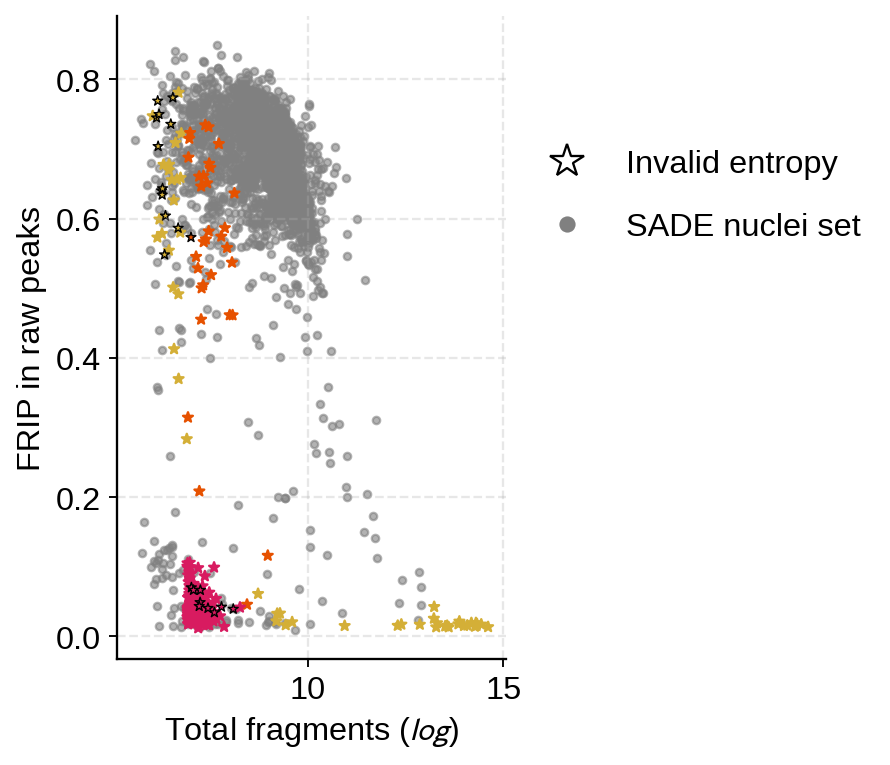

In [15]:

fig = plt.figure(layout="constrained", figsize=(6.6, 5))

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
ax = plt.subplot(gs[1])


not_in_entropy_set = ~union_cell_info['atac_pass_entropy']
invalid_entropy_set = union_cell_info['Entropy'].isna()
# SADE droplets 
ax.scatter( union_cell_info.loc[ (~not_in_entropy_set) , 'log_total_fragments'], union_cell_info.loc[(~not_in_entropy_set) , 'frip_rawpeaks'],  c= 'grey',
            alpha=0.6, 
            s=10,          
            lw=1,      
            marker='o',   
            rasterized=True # Keeps the file size light if saving to PDF
                )
# not in SADE but valid entropy values 
ax.scatter( union_cell_info.loc[not_in_entropy_set & (~invalid_entropy_set) , 'log_total_fragments'], 
            union_cell_info.loc[not_in_entropy_set & (~invalid_entropy_set), 'frip_rawpeaks'], 
            c=union_cell_info.loc[not_in_entropy_set & (~invalid_entropy_set), '_3set_identified_by_atac'].map(cat_colors_map),
            marker='*', 
            s=20,
            alpha=1,
            lw=1,)
# not in SADE and invalid entropy values
ax.scatter( union_cell_info.loc[not_in_entropy_set & invalid_entropy_set, 'log_total_fragments'], union_cell_info.loc[not_in_entropy_set & invalid_entropy_set, 'frip_rawpeaks'], 
           c=union_cell_info.loc[not_in_entropy_set & (invalid_entropy_set), '_3set_identified_by_atac'].map(cat_colors_map),
           edgecolors='black',
           #c='black',
            alpha=1, 
            s=20,          
            lw=0.6,      
            marker='*',   
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)')
ax.set_ylabel('FRIP in raw peaks')

droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Invalid entropy', markersize=15),]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.7) )
ax.add_artist(leg2)  

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', label='SADE nuclei set', markersize=8)] 
# handles += [Line2D([0], [0], marker='*', color='w', markerfacecolor=cat_colors_map[k], label=k, markersize=20) for k in (union_cell_info['_3set_identified_by_atac'][not_in_entropy_set]).unique()]
ax.legend(handles=handles, 
             frameon=False, bbox_to_anchor=(1, 0.74), loc='upper left', ncol=1, )


In [16]:
union_cell_info['_3set_identified_by_atac'].value_counts()

_3set_identified_by_atac
common              1792
TSS unique           189
SADE+TSS, not CR     118
SADE unique          118
SADE+CR, not TSS      73
CR unique             61
CR+TSS, not SADE      33
Name: count, dtype: int64

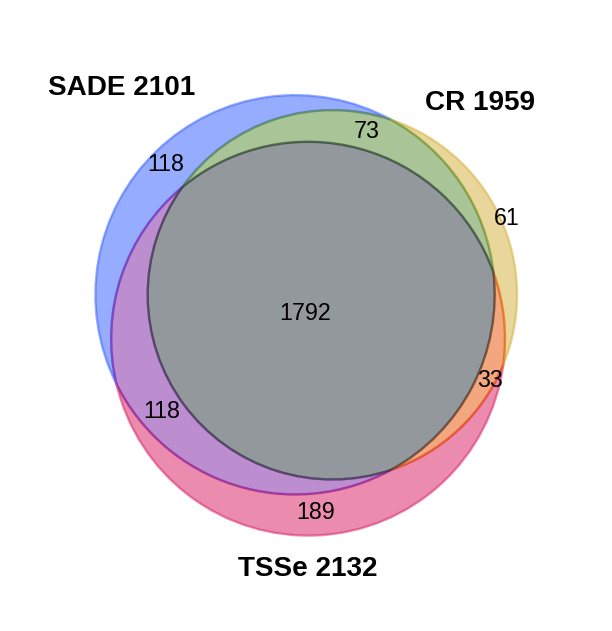

In [17]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
)

fixed_sizes = (0.4, 0.3, 0.4, 0.3, 0.4, 0.2, 0.2) 

fig, ax = plt.subplots(figsize=(4, 4))
v = venn3(venn_sets, set_labels=[f'SADE {union_cell_info[union_cell_info["atac_pass_entropy"]].shape[0]}', 
                                 f'CR {union_cell_info[union_cell_info["atac_pass_CR"]].shape[0]}', 
                                 f'TSSe {union_cell_info[union_cell_info["atac_pass_archr_TSS"]].shape[0]}'], 
                          layout_algorithm=DefaultLayoutAlgorithm(fixed_sizes),  # Use default layout for consistent circle positions
             ax=ax, )


v.get_patch_by_id('100').set_color('#2E5BFF') # Set A
v.get_patch_by_id('010').set_color('#D4AF37') # Set B
v.get_patch_by_id('001').set_color('#D81B60') # Set C

v.get_patch_by_id('110').set_color('#558B2F') # A & B (Green)
v.get_patch_by_id('011').set_color('#E65100') # B & C (Purple)
v.get_patch_by_id('101').set_color('#7B1FA2') # A & C (Orange)
v.get_patch_by_id('111').set_color('#263238') # Triple (Slate)

for patch in v.patches:
    if patch: # Some patches might be None if subsets are empty
        patch.set_alpha(.5)

# Change font size of subset counts
for text in v.subset_labels:
    if text: # Check if label exists
        text.set_fontsize(10)

# Change font size of Set Labels (A, B, C)
for text in v.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

for label in ['100', '010', '001', '110', '011', '101', '111']:
    vl = v.get_label_by_id(label)
    x, y = vl.get_position()
    if label in ['100',  '001', '010']:  # Single sets
        vl.set_position((x * 1.1, y * 1.05 ))
    elif label in ['110',  '101']:  # Double sets
        vl.set_position((x * 1.2, y * 1.1))
    elif label == '011':  # B & C
        vl.set_position((x * 1.1, y * 0.9))

fig.tight_layout()

# Read depth

In [18]:


read_depth_list = [union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == cat, 'log_total_fragments'] for cat in 
                   unique_categories]



mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"Read depth-----------------------------------------")
print(f"------  " + "\t".join(unique_categories))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))


Read depth-----------------------------------------
------  common	SADE unique	CR unique	TSS unique	SADE+CR, not TSS	SADE+TSS, not CR	CR+TSS, not SADE
Mean:  8.9	6.7	9.3	7.2	7.8	7.7	7.5
Median: 9.047761992577476	6.518409280426335	6.7357800142423265	7.094234845924755	6.762729506931879	7.498865901529685	7.383989457978509


In [19]:
frip_list = [union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == cat, 'frip_rawpeaks'] for cat in 
                   unique_categories]

mean_frip = [a.mean() for a in frip_list]
median_frip = [a.median() for a in frip_list]
max_frip = [a.max() for a in frip_list]
print(f"Frip-----------------------------------------")
print(f"------  " + "\t".join(unique_categories))
print(f"Mean:  " + "\t\t".join([f"{mean:.2f}" for mean in mean_frip]))
print(f"Median: " + "\t\t".join([f"{median:.2f}" for median in median_frip]))
print(f"Max:   " + "\t\t".join([f"{max:.4f}" for max in max_frip]))


Frip-----------------------------------------
------  common	SADE unique	CR unique	TSS unique	SADE+CR, not TSS	SADE+TSS, not CR	CR+TSS, not SADE
Mean:  0.67		0.37		0.35		0.04		0.52		0.65		0.55
Median: 0.68		0.31		0.41		0.04		0.66		0.68		0.57
Max:   0.8353		0.8404		0.7812		0.1062		0.8330		0.8494		0.7345


-----------------------------------------
------  atac_pass_CR	atac_pass_entropy	atac_pass_archr_TSS
Mean:  8.9	8.7	8.7
Median: 8.998013113095823	8.87626525995469	8.833171090498773


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


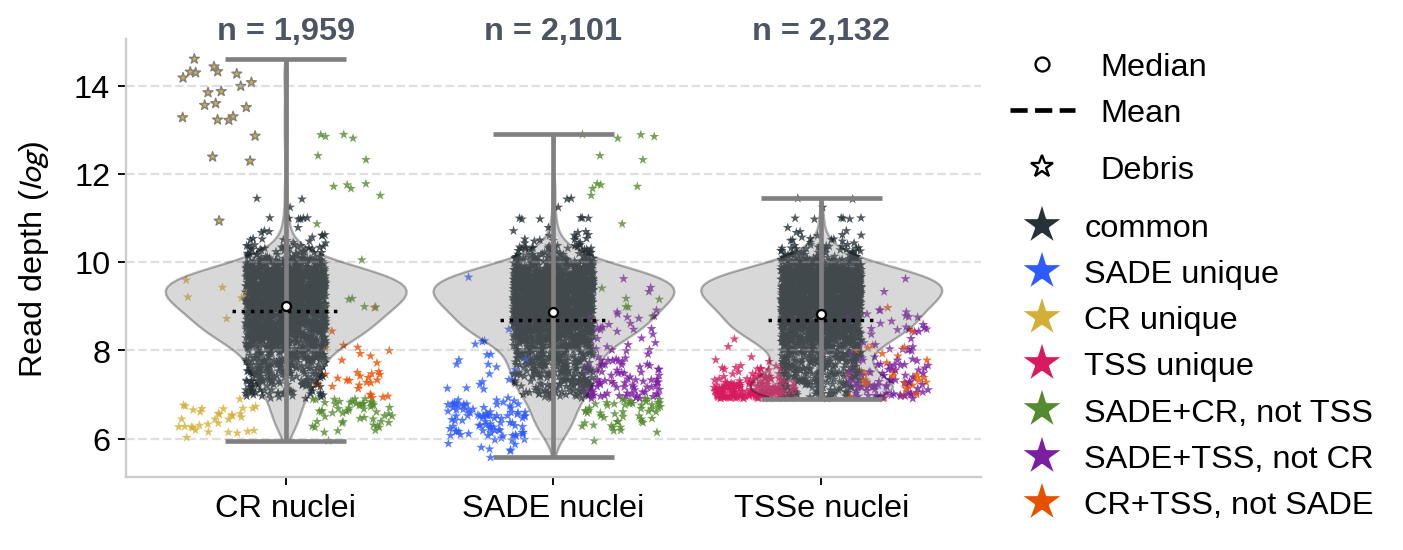

In [20]:

np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

read_depth_list = [union_cell_info.loc[union_cell_info[set_name], 'log_total_fragments'] for set_name in filtering_set]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_colors_map) for set_name in filtering_set]
jitter_position_offset = [union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_position_map) for set_name in filtering_set]
DNA_debris_flag = [union_cell_info.loc[union_cell_info[set_name], 'DNA_debris'] for set_name in filtering_set ]


total_counts = [len(a) for a in read_depth_list]
x_positions = np.arange(len(read_depth_list))


v1 = ax.violinplot(read_depth_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=False, showextrema=True)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for i, group_data in enumerate(read_depth_list):
    # For non-Multiplets cells, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=0.8, s = 20)
    # For Multiplets droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.6, jitter_width=0.15, alpha=1, s=20)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(read_depth_list):
    min, median, max = np.percentile(group_data, [0,  50,  100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.2, x_positions[i] + 0.2, color='black', linestyle=':', lw=1.5, alpha=1, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=1)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in filtering_set], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('Read depth ($log$)', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
leg1 = ax.legend(handles=legend_elements, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.73))
ax.add_artist(leg1) 

droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Debris', markersize=10) ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.6) )
ax.add_artist(leg2)  # Add the second legend back to the axes
handles =[Line2D([0], [0], marker='*', color='w', label=cat_labels_map[c],
                          markerfacecolor=cat_colors_map[c], markersize=20) for c in cat_colors_map.keys()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 0.67), loc='upper left', ncol=1, handletextpad=0.3)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  " + "\t".join(['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))

# FRIP score

-----   atac_pass_CR]  [atac_pass_entropy]  [atac_pass_archr_TSS
mean 	 ['0.654  ', '0.648  ', '0.613  ']
median 	 ['0.680  ', '0.680  ', '0.672  ']


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


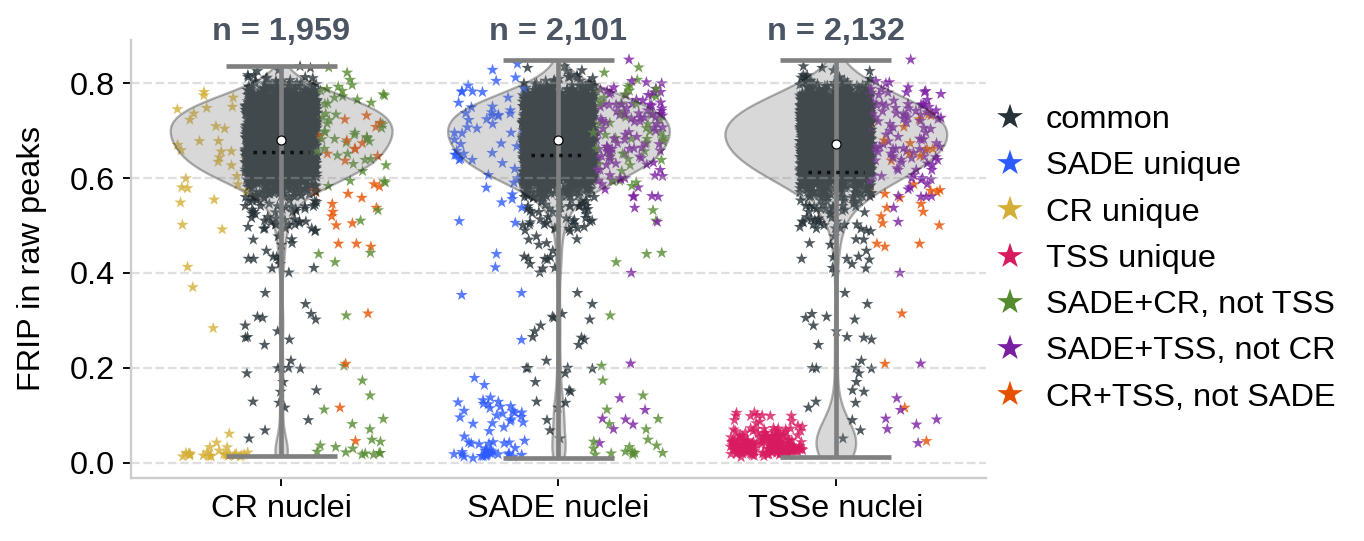

In [21]:
np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

frip_values = [ union_cell_info.loc[union_cell_info[set_name], 'frip_rawpeaks'] for set_name in filtering_set ]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_colors_map) for set_name in filtering_set]
jitter_position_offset = [
    union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_position_map) for set_name in filtering_set
]

x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i] + jitter_position_offset[i], color=this_colors_list[i], alpha=0.8, s=30, jitter_width=0.13)

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.8, 
              showmedians=False, showmeans=False, 
              showextrema=True)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for met in ['cbars', 'cmins', 'cmaxes']:
     v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(frip_values):
    min, median, max = np.percentile(group_data, [0, 50, 100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle=':', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in filtering_set], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('FRIP in raw peaks', labelpad=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
# leg1 = ax.legend(handles=legend_elements, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.73))
# ax.add_artist(leg1)

ax.legend(handles=[Line2D([0], [0], marker='*', color='w', label=cat_labels_map[c],
                          markerfacecolor=cat_colors_map[c], markersize=15) for c in cat_colors_map.keys()],
             frameon=False, bbox_to_anchor=(1.2, 0.5), loc='center', ncol=1,  handletextpad=0.1)

mean_frip_values = [f'{np.mean(a):.3f}  ' for a in frip_values]
median_frip_values = [f'{np.median(a):.3f}  ' for a in frip_values]
print('-----   ' + ']  ['.join(filtering_set))
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# P(closed-state)

In [22]:
union_cell_info['P_closed_state'] = union_cell_info.index.map(lambda x: entropy_df.set_index('atac_bc').loc[x, 'P_closed_state'] if x in entropy_df['atac_bc'].values else np.nan)

-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE
mean 	 ['0.035  ', '0.028  ', '0.024  ']
median 	 ['0.025  ', '0.024  ', '0.024  ']


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


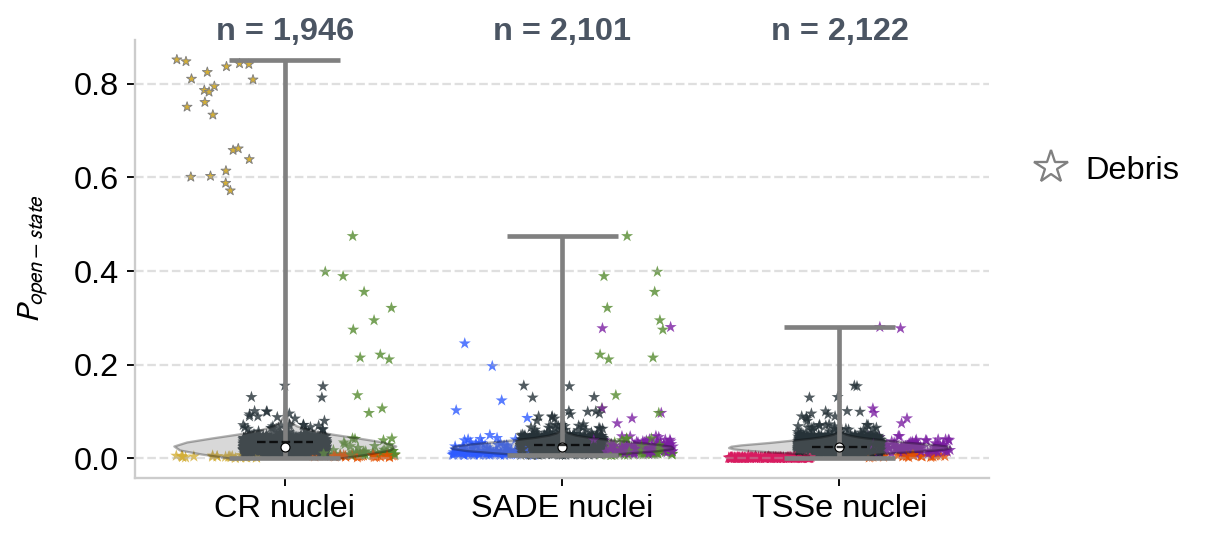

In [23]:
np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

Valid_entropy_cells = union_cell_info.loc[union_cell_info['P_closed_state'].notna()]

p_closed_state_values = [ 1 - Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'P_closed_state'] for set_name in filtering_set ]
this_colors_list = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_3set_identified_by_atac'].map(cat_colors_map) for set_name in filtering_set]
jitter_position_offset = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_3set_identified_by_atac'].map(cat_position_map) for set_name in filtering_set]
DNA_debris_flag = [     Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'DNA_debris'] for set_name in filtering_set ]

x_positions = range(len(p_closed_state_values))

for i, group_data in enumerate(p_closed_state_values):
    # For non-Multiplets cells, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=0.8, s=30)
    # For Multiplets droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.4, jitter_width=0.15, alpha=1, s=20)

v1 = ax.violinplot( [v.dropna() for v in p_closed_state_values], positions=x_positions, widths=0.8, 
              showmedians=False, showmeans=False, showextrema=True)

for met in ['cbars', 'cmins', 'cmaxes']:
     v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(p_closed_state_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

total_counts = [ p_closed_state.shape[0] for p_closed_state in p_closed_state_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in filtering_set], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('$P_{open-state}$', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')


droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15),
                  ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.6), labelspacing=.2 , handletextpad=0.05)


mean_p_closed_state_values = [f'{np.mean(a):.3f}  ' for a in p_closed_state_values]
median_p_closed_state_values = [f'{np.median(a):.3f}  ' for a in p_closed_state_values]
print('-----   ' + ']  ['.join(cat_labels_map))
print(f'mean \t {mean_p_closed_state_values}')
print(f'median \t {median_p_closed_state_values}')

# 2 Set comparison

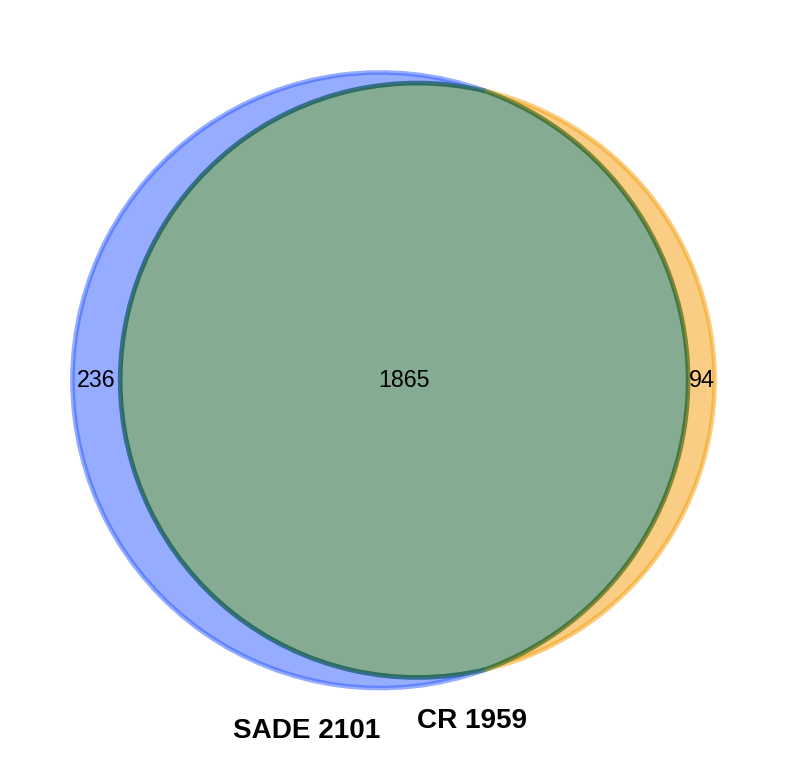

In [24]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    )

fig, ax = plt.subplots()

v = venn2(
    venn_sets[:2], 
                set_labels = (f'SADE {len(venn_sets[0])}',f'CR {len(venn_sets[1])}'), 
                set_colors = ( 'blue', 'orange'), 
                ax = ax)


set_colors = ("#64B1CB", "#D4C645", "#0C5B28")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = v.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width


v.get_patch_by_id('10').set_color('#2E5BFF') # Set A
v.get_patch_by_id('01').set_color('#F59E0B') # Set B
v.get_patch_by_id('11').set_color('#0C5B28') # Set C


for patch in v.patches:
    if patch: # Some patches might be None if subsets are empty
        patch.set_alpha(.5)

# Change font size of subset counts
for text in v.subset_labels:
    if text: # Check if label exists
        text.set_fontsize(10)

# Change font size of Set Labels (A, B, C)
for text in v.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

for label in ['10', '01', '11']:
    vl = v.get_label_by_id(label)
    x, y = vl.get_position()
    vl.set_position((x * 1, y * 1.05 ))
    # elif label in ['110',  '101']:  # Double sets
    #     vl.set_position((x * 1.2, y * 1.1))
    # elif label == '011':  # B & C
    #     vl.set_position((x * 1.1, y * 0.9))

fig.tight_layout()

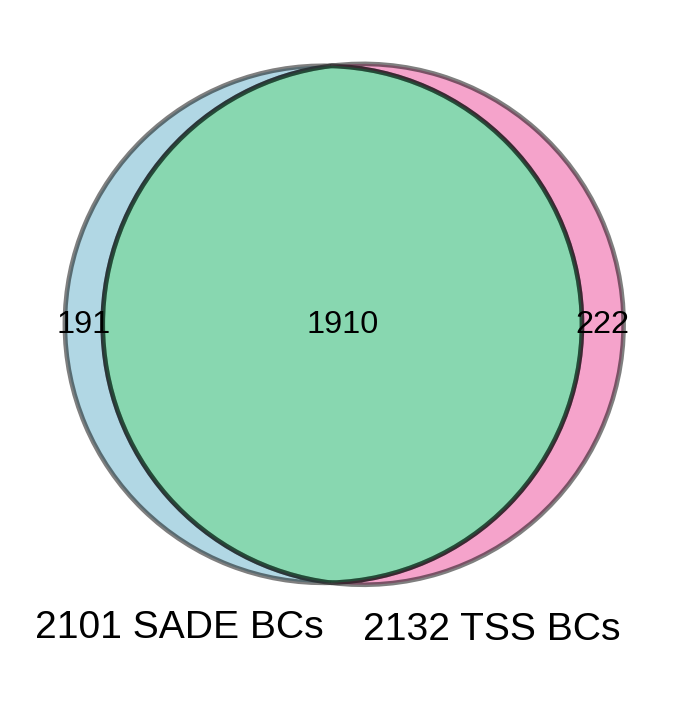

In [25]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    )


fig1, ax1 = plt.subplots()

vennfig = venn2(
    venn_sets[:2], 
                set_labels = (f'{len(venn_sets[0])} SADE BCs\n',f'{len(venn_sets[1])} TSS BCs\n'), 
                ax = ax1)

set_colors = ('#ADD8E6', '#FFFFE0', '#FFB6C1') 
set_colors = ("#64B1CB", "#D67022", "#0C5B28")  
set_colors = ("#64B1CB", "#EC4899", "#13B062")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = vennfig.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width

# plt.title('SADE vs TSS', fontsize=16)


In [1]:
2101 + 2132 - 1910

2323

In [26]:
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,total_fragments,Nfrag_in_rawpeaks,frip_rawpeaks,log_entropy,log_total_fragments
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA,none,none,none,537,0,0.000000,-7.591694,6.287859
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT,both,both,common,4841,2740,0.565999,-2.294087,8.485083


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


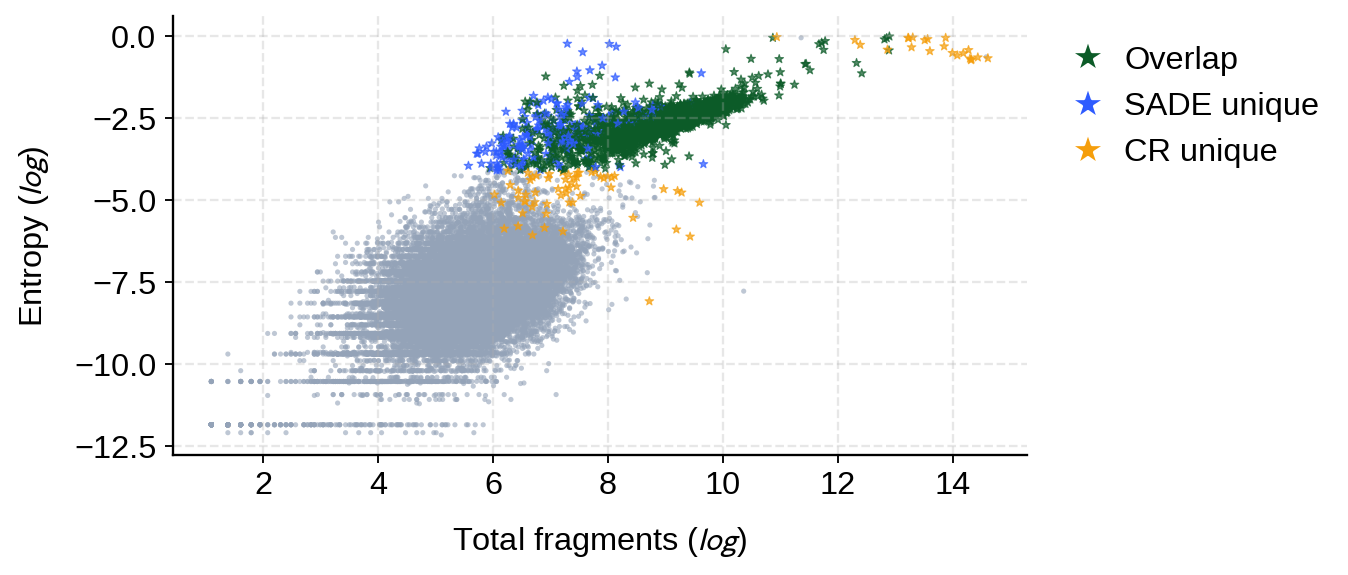

In [28]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])


none_index = entropy_df['_2set_identified_by_atac_SC'] == 'none'
permitted_index = ~none_index
v = ax.scatter( entropy_df.loc[none_index]['log_total_fragments'], entropy_df.loc[none_index]['log_entropy'] ,  
            c= entropy_df.loc[none_index]['_2set_identified_by_atac_SC'].map(SADEvsCR_colors_map),
            alpha=0.6,
            marker='o', 
                s=5,          
                lw=0,         
                rasterized=True # Keeps the file size light if saving to PDF
                        )


ax.scatter( entropy_df.loc[permitted_index]['log_total_fragments'], entropy_df.loc[permitted_index]['log_entropy'] ,  
            c= entropy_df.loc[permitted_index]['_2set_identified_by_atac_SC'].map(SADEvsCR_colors_map),
            alpha=0.7,
            marker='*', 
                s=15,          
                lw=0.5,         
                rasterized=True # Keeps the file size light if saving to PDF
                        )

# 4. Clean up the Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)', labelpad=10)
ax.set_ylabel('Entropy ($log$)', labelpad=10)
# ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)

handles = [Line2D([0], [0], marker='*', color='w', markerfacecolor=SADEvsCR_colors_map[c], label=SADEvsCR_label_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ( 'none', 'tss_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.1)


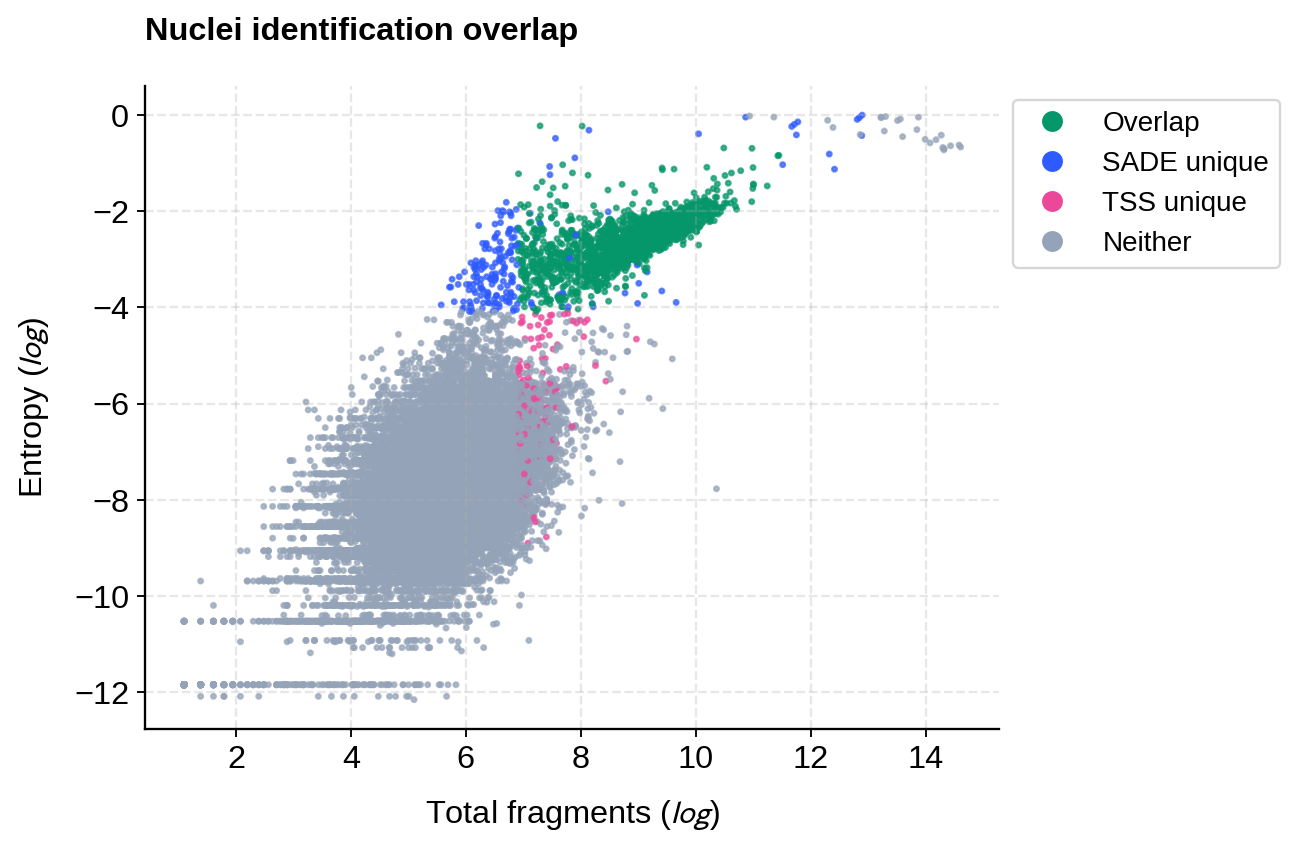

In [ ]:
fig, ax = plt.subplots( figsize=(6.6, 5) )

twosets_colors_map = {'both':"#059669", 'entropy_only':'#2E5BFF', 'tss_only':"#EC4899", 'none':'#94A3B8'}
twosets_labels_map = {'both':'Overlap', 'entropy_only':'SADE unique', 'tss_only':'TSS unique', 'none':'Neither'}
ax.scatter( entropy_df['log_total_fragments'], entropy_df['log_entropy'],  c= entropy_df['_2set_identified_by_atac_ST'].map(twosets_colors_map), 
            alpha=0.7, 
            s=4,          
            lw=1,         
            rasterized=True # Keeps the file size light if saving to PDF
                )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)', labelpad=10)
ax.set_ylabel('Entropy ($log$)', labelpad=10)
ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)


handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in twosets_colors_map.items()]

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=twosets_labels_map[c],
                          markerfacecolor=twosets_colors_map[c], markersize=10) for c in twosets_colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=12)


plt.show()

In [ ]:
SADEvsCR_colors_map

{'both': '#0C5B28',
 'entropy_only': '#2E5BFF',
 'cr_only': '#F59E0B',
 'none': '#94A3B8',
 'tss_only': '#D81B60'}

_3set_identified_by_atac
CR unique           12
TSS unique           9
CR+TSS, not SADE     1
Name: count, dtype: int64
                          count      mean       std       min       25%  \
_3set_identified_by_atac                                                  
CR unique                  12.0  0.677933  0.077673  0.548387  0.626765   
CR+TSS, not SADE            1.0  0.573248       NaN  0.573248  0.573248   
TSS unique                  9.0  0.050321  0.013691  0.034466  0.040636   

                               50%       75%       max  
_3set_identified_by_atac                                
CR unique                 0.673707  0.746291  0.773913  
CR+TSS, not SADE          0.573248  0.573248  0.573248  
TSS unique                0.043478  0.066524  0.070270  


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


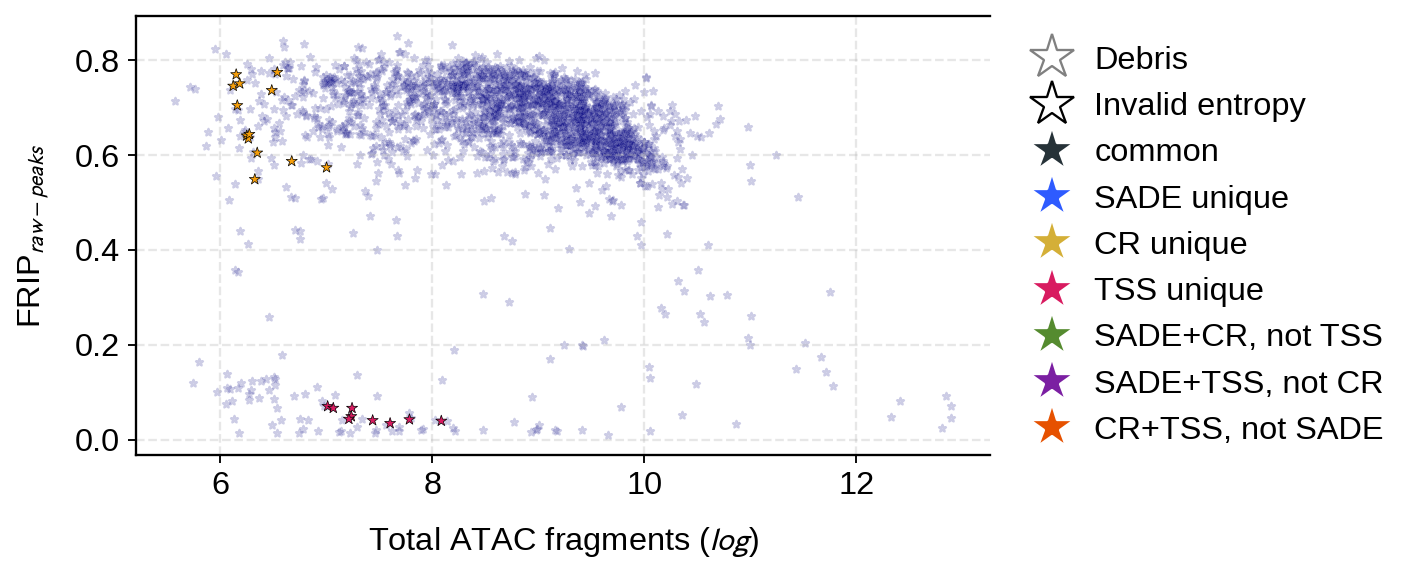

In [ ]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

dna_debris_index = union_cell_info['DNA_debris'] == 'YES'
invalid_entropy_index = union_cell_info['Entropy'].isna()

# Only the droplets in the union set are colored by their category 
## For non-DNA-debris droplets, color by their category
ax.scatter( union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'log_total_fragments'], union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'frip_rawpeaks'],  edgecolors= 'navy', 
            c='white', alpha=0.2, 
            s=10,          
            lw=1,      
            marker='*', 
              
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For invalid droplets, edgecolor in grey
ax.scatter( union_cell_info.loc[dna_debris_index, 'log_total_fragments'], union_cell_info.loc[dna_debris_index, 'frip_rawpeaks'],  c= union_cell_info.loc[dna_debris_index, '_2set_identified_by_atac_SC_mod'].map(cat_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.5,      
            marker='*',   
            edgecolors='grey',
            rasterized=True # Keeps the file size light if saving to PDF
#                 )
## For droplets with invalid entropy, edgecolor in red 
ax.scatter( union_cell_info.loc[invalid_entropy_index, 'log_total_fragments'], union_cell_info.loc[invalid_entropy_index, 'frip_rawpeaks'],  c= union_cell_info.loc[invalid_entropy_index, '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.3,      
            marker='*',   
            edgecolors='black',
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log$)', labelpad=10)
ax.set_ylabel('FRIP$_{raw-peaks}$', labelpad=10)


handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none',  label='Debris', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none',  label='Invalid entropy', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w', markerfacecolor=v, label=k, markersize=20) for k, v in cat_colors_map.items()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.3)

print(
union_cell_info.loc[invalid_entropy_index, '_3set_identified_by_atac'].value_counts()
)
print(
union_cell_info.loc[invalid_entropy_index].groupby('_3set_identified_by_atac')['frip_rawpeaks'].describe()
)

In [ ]:
union_cell_info.loc[invalid_entropy_index, '_2set_identified_by_atac_SC_mod']#.map(SADEvsCR_colors_map), 

atac_bc
AAGCTAGGTTACTTCT    tss_unique
ACATTACTCATTACAC       cr_only
ATCCTAGTCCTGGATC       cr_only
ATCGTGACAATAGAAG       cr_only
ATGCGGATCGCTATAT       cr_only
ATTGAACCACTCCCTT    tss_unique
CAGCCTAGTCGTAATC       cr_only
CATTGCCAGGGTTGGC    tss_unique
CCTAACTCATAGCGAC    tss_unique
CGTGAACCAAGGACGA       cr_only
CGTGCCTCATAACGAT       cr_only
CTATGTCCACCTGTAT       cr_only
GATCCAACACCAAAGC    tss_unique
GGAGCATGTGAGGAAG       cr_only
GGTTTACGTAGGAGGA       cr_only
GTCTATGTCGCCTGTG    tss_unique
TATCCATAGGCGCGAT       cr_only
TGCTCAATCATAGCTT    tss_unique
TGCTGGAAGTCAACAA    tss_unique
TGGTTCTCATTGCCCA    tss_unique
TTGGCTATCCTCTACT       cr_only
TTGGTCCAGGTACCGA       cr_only
Name: _2set_identified_by_atac_SC_mod, dtype: object

## Emphasize on comparison between SADE vs CR, then added on TSSe unique barcodes 

-----------------------------------------
------  atac_pass_CR	atac_pass_entropy	atac_pass_archr_TSS
Mean:  8.9	8.7
Median: 8.998013113095823	8.87626525995469


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


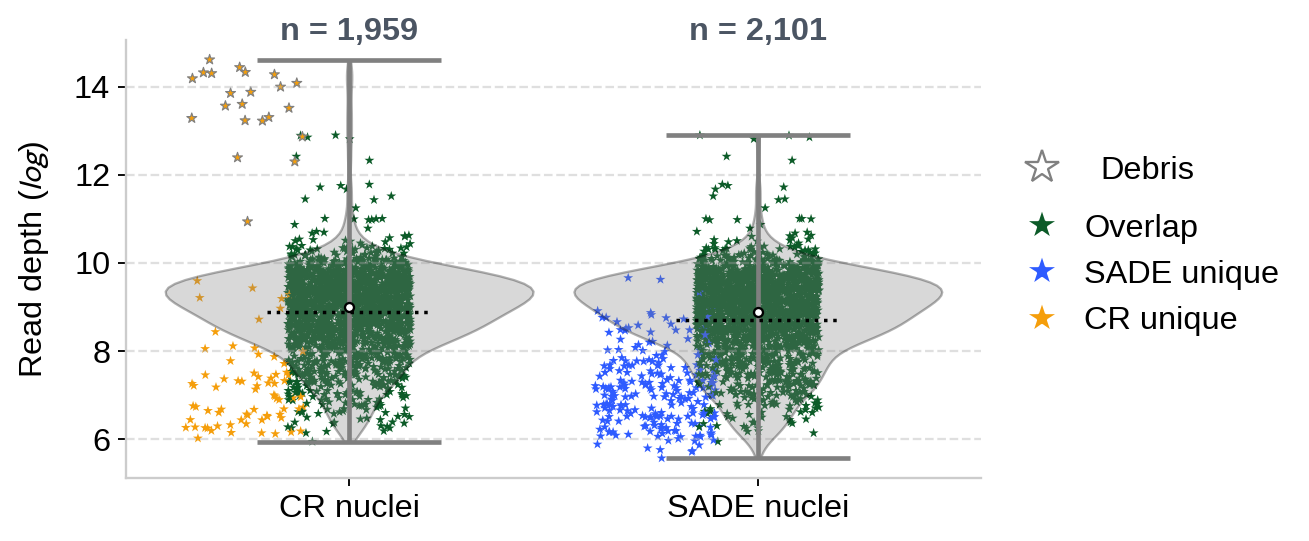

In [ ]:

np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

read_depth_list = [union_cell_info.loc[union_cell_info[set_name], 'log_total_fragments'] for set_name in SADEvsCR_filteringset]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for set_name in SADEvsCR_filteringset]
jitter_position_offset = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for set_name in SADEvsCR_filteringset]
DNA_debris_flag = [union_cell_info.loc[union_cell_info[set_name], 'DNA_debris'] for set_name in SADEvsCR_filteringset ]


total_counts = [len(a) for a in read_depth_list]
x_positions = np.arange(len(read_depth_list))


v1 = ax.violinplot(read_depth_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=False, showextrema=True)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for i, group_data in enumerate(read_depth_list):
    # For non-Multiplets cells, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=1, s = 20, lw=1)
    # For Multiplets droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.5, jitter_width=0.15, alpha=1, s=20)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(read_depth_list):
    min, median, max = np.percentile(group_data, [0,  50,  100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.2, x_positions[i] + 0.2, color='black', linestyle=':', lw=1.5, alpha=1, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=1)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in SADEvsCR_filteringset], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('Read depth ($log$)', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')



droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15) ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.6) )
ax.add_artist(leg2)  # Add the second legend back to the axes
handles =[Line2D([0], [0], marker='*', color='w', label=SADEvsCR_label_map[c],
                          markerfacecolor=SADEvsCR_colors_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ('none', 'tss_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 0.67), loc='upper left', ncol=1, handletextpad=0.3)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  " + "\t".join(['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))

-----------------------------------------
------  atac_pass_CR	atac_pass_entropy	atac_pass_archr_TSS
Mean:  8.9	8.7
Median: 8.998013113095823	8.87626525995469


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


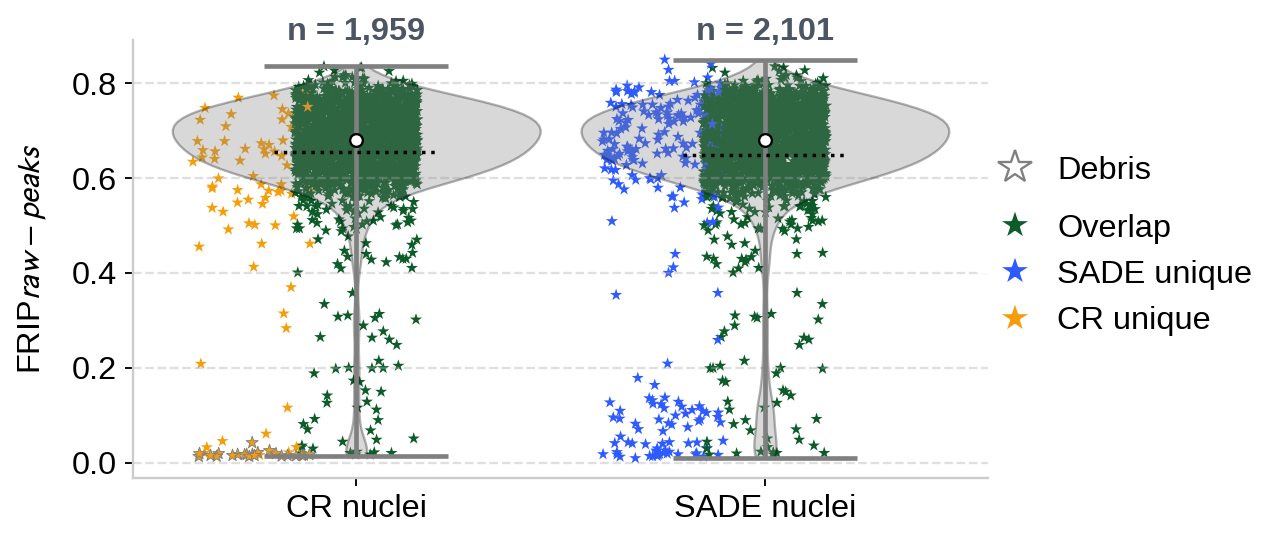

In [ ]:

np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

frip_list = [union_cell_info.loc[union_cell_info[set_name], 'frip_rawpeaks'] for set_name in SADEvsCR_filteringset]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for set_name in SADEvsCR_filteringset]
jitter_position_offset = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for set_name in SADEvsCR_filteringset]
DNA_debris_flag = [union_cell_info.loc[union_cell_info[set_name], 'DNA_debris'] for set_name in SADEvsCR_filteringset ]


total_counts = [len(a) for a in frip_list]
x_positions = np.arange(len(frip_list))


v1 = ax.violinplot(frip_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=False, showextrema=True)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for i, group_data in enumerate(frip_list):
    # For non-debris droplets, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=1, s = 30, lw=1)
    # For debris droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.4, jitter_width=0.15, alpha=1, s=30)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(frip_list):
    min, median, max = np.percentile(group_data, [0,  50,  100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.2, x_positions[i] + 0.2, color='black', linestyle=':', lw=1.5, alpha=1, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=30, zorder=3, edgecolor='black', lw=1)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in SADEvsCR_filteringset], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('FRIP$raw-peaks$', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')



droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15) ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.96, 0.6) , handletextpad=0.3)
ax.add_artist(leg2)  # Add the second legend back to the axes
handles =[Line2D([0], [0], marker='*', color='w', label=SADEvsCR_label_map[c],
                          markerfacecolor=SADEvsCR_colors_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ('none', 'tss_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(0.96, 0.67), loc='upper left', ncol=1, handletextpad=0.3)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  " + "\t".join(['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))

-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE
mean 	 ['0.035  ', '0.028  ']
median 	 ['0.025  ', '0.024  ']


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


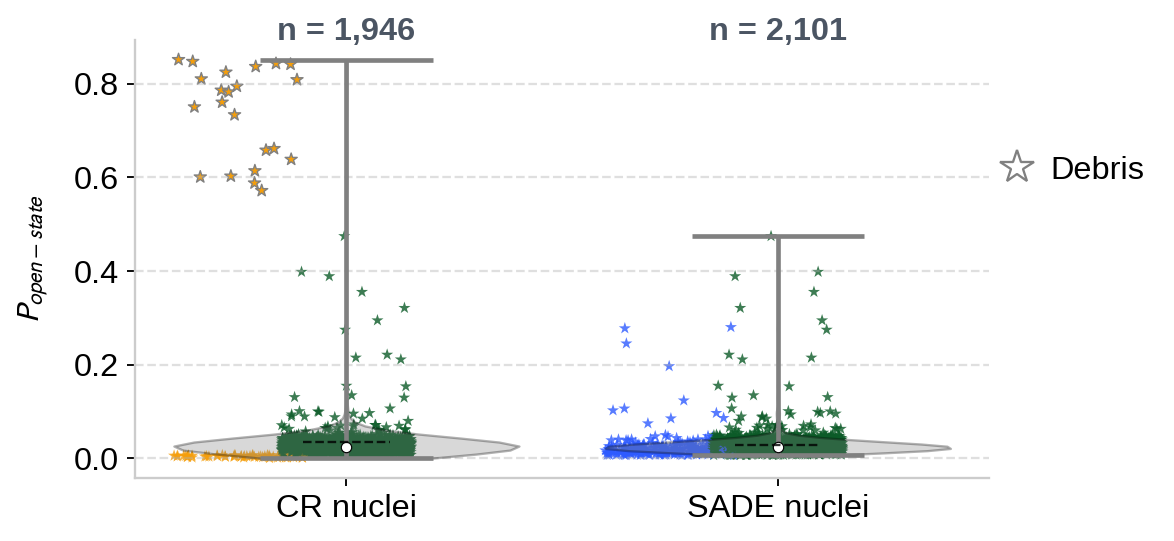

In [ ]:
np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

Valid_entropy_cells = union_cell_info.loc[union_cell_info['P_closed_state'].notna()]

p_closed_state_values = [ 1 - Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'P_closed_state'] for set_name in SADEvsCR_filteringset ]
this_colors_list = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for set_name in SADEvsCR_filteringset]
jitter_position_offset = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for set_name in SADEvsCR_filteringset]
DNA_debris_flag = [     Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'DNA_debris'] for set_name in SADEvsCR_filteringset ]

x_positions = range(len(p_closed_state_values))

for i, group_data in enumerate(p_closed_state_values):
    # For non-debris droplets, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=0.8, s=30)
    # For debris droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.6, jitter_width=0.15, alpha=1, s=30)

v1 = ax.violinplot( [v.dropna() for v in p_closed_state_values], positions=x_positions, widths=0.8, 
              showmedians=False, showmeans=False, showextrema=True)

for met in ['cbars', 'cmins', 'cmaxes']:
     v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(p_closed_state_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=20, zorder=3, edgecolor='black', lw=0.5)

total_counts = [ p_closed_state.shape[0] for p_closed_state in p_closed_state_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in SADEvsCR_filteringset], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('$P_{open-state}$', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')


droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15),
                  ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.96, 0.6), labelspacing=.2 , handletextpad=0.05)


mean_p_closed_state_values = [f'{np.mean(a):.3f}  ' for a in p_closed_state_values]
median_p_closed_state_values = [f'{np.median(a):.3f}  ' for a in p_closed_state_values]
print('-----   ' + ']  ['.join(cat_labels_map))
print(f'mean \t {mean_p_closed_state_values}')
print(f'median \t {median_p_closed_state_values}')

## With RNA info

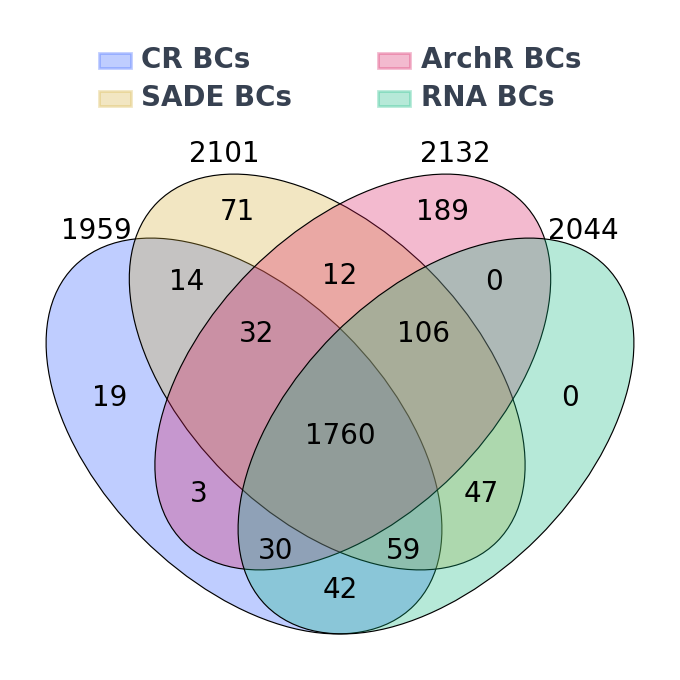

In [ ]:
from venny4py.venny4py import *




venn_4sets = {
    'CR BCs': set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    'SADE BCs':  set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    'ArchR BCs': set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    'RNA BCs': set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index) }

fig = venny4py(sets=venn_4sets, colors=['#2E5BFF', "#D4AF37", '#D81B60', '#10B981'])
ax = plt.gca()

# Make the circles look soft and premium
for patch in ax.get_children():
    if isinstance(patch, plt.Circle) or 'PathPatch' in str(type(patch)):
        patch.set_alpha(0.6)       # Soften the overlap
        patch.set_edgecolor('white') # White borders make colors "pop"
        patch.set_linewidth(1.5)

# Improve text readability
for text in ax.findobj(plt.Text):
    text.set_fontsize(10)
    # Highlight the set labels (usually the ones with 'BCs')
    if 'BCs' in text.get_text():
        text.set_fontweight('bold')
        text.set_fontsize(10)
        text.set_color('#374151') # Deep charcoal instead of pure black


ax.axis('off')

plt.tight_layout()
plt.show()

In [83]:
rna_info_file = os.path.join(Union_cell_subdir, 'Union_3set_rna_info.tsv')
union_cell_rna_info = pd.read_csv(rna_info_file, sep='\t', index_col=1)
union_cell_rna_info.head(2)

,rna_barcodes,rna_pass_CR,leiden_RNA_scVI,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%
atac_barcodes,,,,,,,,
ACAGCGGGTTTGTAGC,AAACAGCCAGGCTACT,True,1,3931.0,8.276903,1772,519.0,13.202747
CATTTAGGTAACAGCA,AAACATGCAAGGATTA,True,3,3566.0,8.179481,1689,401.0,11.245092


In [85]:
col_list = ['total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%']
for col in col_list:
    union_cell_info[col] = union_cell_info.index.map(union_cell_rna_info[col])

Text(0, 0.5, 'Total RNA UMI ($log_{1p}$)')

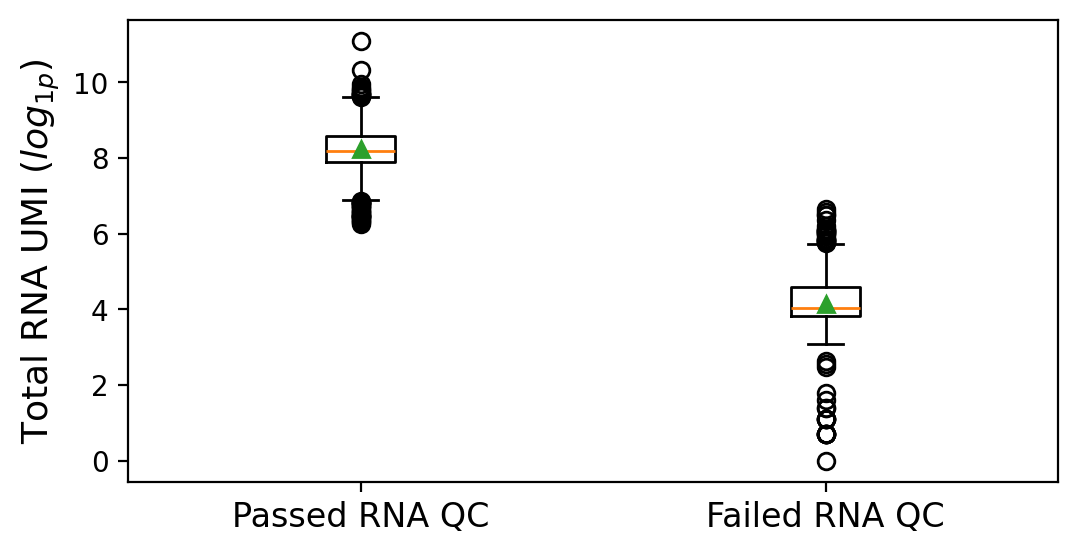

In [ ]:
fig, ax = plt.subplots( figsize=(6, 3) )

rna_umi = [union_cell_info.loc[union_cell_info['rna_pass_CR'], 'total_RNA_UMI'],
           union_cell_info.loc[~union_cell_info['rna_pass_CR'], 'total_RNA_UMI'].dropna(),
]
rna_umi = [x) for x in rna_umi]

x_pos = range(len(rna_umi))
ax.boxplot(rna_umi, positions=x_pos, showmeans=True)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Passed RNA QC', 'Failed RNA QC'], fontsize=12)
ax.set_ylabel('Total RNA UMI ($log_{1p}$)', fontsize=13)

In [41]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_CR').size()

atac_pass_CR
False     153
True     1891
dtype: int64

In [42]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_entropy').size()

atac_pass_entropy
False      72
True     1972
dtype: int64

In [44]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_archr_TSS').size()

atac_pass_archr_TSS
False     148
True     1896
dtype: int64

In [48]:
1972 / 2044, 1896 / 2044, 1891 / 2044

(0.9647749510763209, 0.9275929549902152, 0.925146771037182)

In [46]:
union_cell_info['rna_pass_CR'].sum()

np.int64(2044)

### --

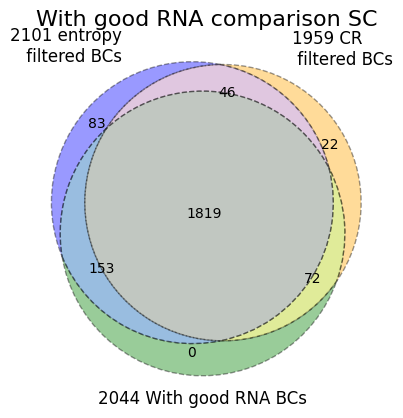

In [27]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\n filtered BCs',f'{len(venn_sets[1])} CR \n filtered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison SC', fontsize=16)
plt.show()

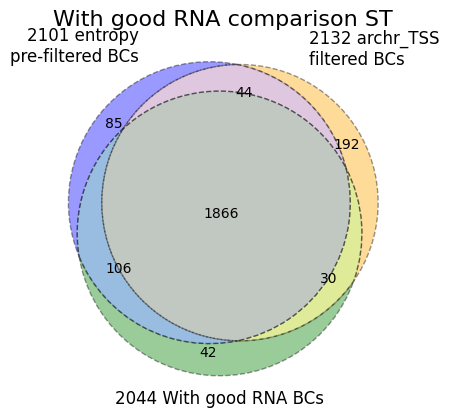

In [17]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} archr_TSS \nfiltered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison ST', fontsize=16)
plt.show()